In [1]:
# Primero vamos a instalar la librería para leer PDFs
!pip install pdfplumber matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 61.2 MB/s eta 0:00:00


In [2]:
# Descargamos el modelo de español si no está instalado
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 86.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
# Necesario para dividir en oraciones
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [7]:
# Código de Análisis TF-IDF
import pdfplumber
import pandas as pd
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

# --- CONFIGURACIÓN ---
archivo_pdf = "2026-05-24-Informe-a-la-Nacion-2026.pdf"

# Cargamos Spacy
nlp = spacy.load("es_core_news_sm")

In [8]:
archivo_pdf = "2026-05-24-Informe-a-la-Nacion-2026.pdf"

# --- 1. EXTRACCIÓN DE TEXTO DEL PDF ---
def extraer_texto_pdf(ruta_archivo):
    texto_completo = ""
    try:
        with pdfplumber.open(ruta_archivo) as pdf:
            print(f"Leyendo {len(pdf.pages)} páginas del PDF...")
            for pagina in pdf.pages:
                texto_completo += pagina.extract_text() + " "
        return texto_completo
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{ruta_archivo}' en la carpeta actual.")
        return None

In [9]:
# --- 2. PREPROCESADO (Limpieza y Lematización) ---
def limpiar_y_lematizar(texto):
    doc = nlp(texto.lower())
    lemmas = []
    for token in doc:
        # Quitamos stopwords, puntuación y nos quedamos solo con palabras alfabéticas
        if token.is_alpha and not (token.is_stop or token.is_punct):
            lemmas.append(token.lemma_)
    return " ".join(lemmas)

In [10]:
# --- 3. CREACIÓN DEL CORPUS DE COMPARACIÓN INTELIGENTE ---
# El objetivo es crear contraste semántico.
# Texto Genérico 1: Política Internacional/Diplomática (Suena a discurso, pero trata de otros temas)
texto_generico_diplomacia = """
La diplomacia internacional fortalece las relaciones bilaterales entre naciones.
Los presidentes asistieron a la cumbre climática para discutir el calentamiento global y acuerdos comerciales.
Es fundamental mantener el dialogo y la cooperación mutua para el desarrollo sostenible de la región.
Las embajadas trabajan en文化交流 y protección de los ciudadanos en el extranjero.
"""

# Texto Genérico 2: Deportes y Cultura (Contexto totalmente distinto)
texto_generico_deportes = """
El seleccionado nacional ganó el campeonato mundial de fútbol en una final emocionante.
Los atletas olímpicos demostraron su garra y disciplina en las competencias.
El festival de música reunió a miles de personas en la plaza principal.
El deporte une a los pueblos y fomenta valores de respeto y trabajo en equipo.
"""

# Texto Genérico 3: Tecnología y Ciencia (Contexto moderno pero ajeno a la política local)
texto_generico_tecnologia = """
El avance de la inteligencia artificial permite nuevos descubrimientos en medicina y robótica.
Las startups tecnológicas están innovando con aplicaciones móviles y software avanzado.
La exploración espacial busca rastros de vida en el planeta marte.
La ciberseguridad es crucial para proteger la información en las redes sociales.
"""

# Ejecutamos la limpieza de tu discurso
discurso_crudo = extraer_texto_pdf(archivo_pdf)

if discurso_crudo:
    # Limpieza del discurso
    print("Procesando el discurso principal...")
    discurso_limpio = limpiar_y_lematizar(discurso_crudo)

    # Limpieza de los textos genéricos (Importante: deben pasar por el mismo proceso)
    generico_1 = limpiar_y_lematizar(texto_generico_diplomacia)
    generico_2 = limpiar_y_lematizar(texto_generico_deportes)
    generico_3 = limpiar_y_lematizar(texto_generico_tecnologia)

    # Creamos el corpus completo: [Discurso, Genérico 1, Genérico 2, Genérico 3]
    corpus_completo = [discurso_limpio, generico_1, generico_2, generico_3]

     # --- 4. APLICANDO TF-IDF ---
    # max_features=5000 para limitar el análisis a las palabras más relevantes si el vocabulario es enorme
    vectorizer = TfidfVectorizer(max_features=5000, norm='l2', use_idf=True, smooth_idf=True)

    tfidf_matrix = vectorizer.fit_transform(corpus_completo)

      # --- 5. ANÁLISIS DE RESULTADOS ---
    feature_names = vectorizer.get_feature_names_out()

    # Extraemos solo la primera fila (índice 0), que corresponde a tu Informe a la Nación
    tfidf_scores = tfidf_matrix[0].toarray()[0]

    # Creamos el DataFrame para análisis
    df_tfidf = pd.DataFrame({'Palabra': feature_names, 'Score TF-IDF': tfidf_scores})

    # Filtramos y ordenamos
    # Buscamos palabras con un score significativo (ej. > 0.05) y tomamos el Top 20
    top_palabras_tfidf = df_tfidf[df_tfidf['Score TF-IDF'] > 0.05].sort_values(by='Score TF-IDF', ascending=False).head(20)

    print("\n" + "="*60)
    print(f"  TEMAS ÚNICOS DEL INFORME A LA NACIÓN 2026 (TF-IDF)")
    print("="*60)
    print("(Comparado contra Diplomacia, Deportes y Tecnología)\n")
    print(top_palabras_tfidf.to_string(index=False))

    print("\n--- ANÁLISIS DE LOS RESULTADOS ---")
    print("Observa que palabras comunes como 'presidente' o 'año' probablemente")
    print("bajaran de ranking, porque también aparecen en los textos de comparación.")
    print("Sin embargo, términos específicos como 'sinohydro', 'mafias', 'pobreza'")
    print("o 'coca' deberían tener valores altos, ya que son EXCLUSIVOS de este discurso.")

else:
    print("No se pudo realizar el análisis.")

Leyendo 7 páginas del PDF...
Procesando el discurso principal...

  TEMAS ÚNICOS DEL INFORME A LA NACIÓN 2026 (TF-IDF)
(Comparado contra Diplomacia, Deportes y Tecnología)

    Palabra  Score TF-IDF
    ecuador      0.430109
       país      0.366389
        año      0.270809
   gobierno      0.191160
      señor      0.191160
     señora      0.191160
  república      0.143370
      quito      0.127440
         él      0.127440
presidencia      0.111510
       obra      0.111510
       mayo      0.111510
   nacional      0.100475
ecuatoriano      0.095580
     futuro      0.095580
  necesitar      0.095580
    público      0.079650
     volver      0.079650
   historia      0.079650
    empezar      0.079650

--- ANÁLISIS DE LOS RESULTADOS ---
Observa que palabras comunes como 'presidente' o 'año' probablemente
bajaran de ranking, porque también aparecen en los textos de comparación.
Sin embargo, términos específicos como 'sinohydro', 'mafias', 'pobreza'
o 'coca' deberían tener valore

Al usar textos sobre "Diplomacia" y "Tecnología", el algoritmo entenderá que palabras como "presidente" o "gobierno" son normales en cualquier texto político. Les dará un puntaje TF-IDF más bajo.

Palabras que vimos en el texto como "Sinohydro", "Coca Codo", "Mafias", "Quinto Puente" o "Pobreza" son muy raras en los textos de tecnología o deporte. El algoritmo les dará el puntaje más alto posible, identificándolas como las "huellas digitales" únicas de este discurso.



In [11]:
# Cargamos Spacy
try:
    nlp = spacy.load("es_core_news_sm")
except OSError:
    print("Error: Modelo de Spacy no encontrado.")
    exit()

In [12]:
# --- 2. PREPROCESADO MEJORADO ---
def limpiar_texto(texto):
    doc = nlp(texto.lower())
    tokens = []
    for token in doc:
        if token.is_alpha and not (token.is_stop or token.is_punct):
            tokens.append(token.lemma_)
    return " ".join(tokens)

In [15]:
# --- 3. DEFINICIÓN DE STOPWORDS PERSONALIZADOS ---
# Aquí agregamos palabras que salieron en tu análisis anterior pero que no nos sirven
stopwords_personalizadas = [
    "señor", "señora", "país", "ecuador", "hacer", "año", "él",
    "gobierno", "poder", "tod", "ser", "est", "ir", "ver"
]

In [16]:
# --- EJECUCIÓN ---
discurso_crudo = extraer_texto_pdf(archivo_pdf)

if discurso_crudo:
    print("Dividiendo el discurso en oraciones para análisis profundo...")

    # A. Dividir el texto en oraciones (sentences)
    oraciones = nltk.sent_tokenize(discurso_crudo)

    # B. Limpiar cada oración individualmente
    corpus_oraciones = [limpiar_texto(oracion) for oracion in oraciones]

    # C. Aplicar TF-IDF sobre las oraciones
    # max_df=0.5: Ignorar palabras que aparecen en más del 50% de las oraciones (Esto eliminará "Ecuador" y "País")
    # min_df=1: Incluir palabras que aparezcan al menos una vez
    vectorizer = TfidfVectorizer(max_df=0.5, min_df=1, stop_words=stopwords_personalizadas)

    tfidf_matrix = vectorizer.fit_transform(corpus_oraciones)

    # --- 4. ANÁLISIS: SUMAR PUNTAJES ---
    # Como tenemos una matriz de (Oraciones x Palabras), queremos saber el peso total de CADA palabra en todo el discurso.
    # Sumamos los scores de cada palabra a través de todas las oraciones.
    scores_totales = tfidf_matrix.sum(axis=0).A1

    feature_names = vectorizer.get_feature_names_out()

    # Crear DataFrame
    df_resultados = pd.DataFrame({'Palabra': feature_names, 'Score TF-IDF Acumulado': scores_totales})

    # Ordenar y tomar Top 20
    top_palabras = df_resultados.sort_values(by='Score TF-IDF Acumulado', ascending=False).head(25)

    print("\n" + "="*70)
    print(f"  TEMAS CLAVE ÚNICOS (Análisis por Oraciones)")
    print("="*70)
    print("(Se han penalizado palabras que se repiten en todo el texto)\n")
    print(top_palabras.to_string(index=False))

    # --- 5. ANÁLISIS CUALITATIVO ---
    print("\n--- INTERPRETACIÓN ---")
    top_words_list = top_palabras['Palabra'].tolist()

    if 'sinohydro' in top_words_list:
        print("✅ Se detectó 'Sinohydro' (Caso de corrupción específico).")
    if 'mafia' in top_words_list or 'luchar' in top_words_list:
        print("✅ Se detectó el tema de Seguridad/Mafias.")
    if 'pobreza' in top_words_list:
        print("✅ Se detectó el tema Social/Pobreza.")
    if 'coca' in top_words_list or 'sinclair' in top_words_list:
        print("✅ Se detectaron referencias a Coca Codo Sinclair.")

else:
    print("No se pudo leer el archivo.")

Leyendo 7 páginas del PDF...
Dividiendo el discurso en oraciones para análisis profundo...

  TEMAS CLAVE ÚNICOS (Análisis por Oraciones)
(Se han penalizado palabras que se repiten en todo el texto)

    Palabra  Score TF-IDF Acumulado
      lucha                2.598493
       obra                2.560246
    empezar                2.396812
  república                2.375267
      quito                2.291490
  necesitar                2.288070
   historia                2.237650
     luchar                2.231311
     futuro                2.139131
ecuatoriano                2.079933
       mayo                2.039789
presidencia                2.039789
    cambiar                1.991659
  recuperar                1.918973
   combatir                1.806382
     camino                1.796797
     volver                1.728053
   decisión                1.722666
    avanzar                1.652560
      mover                1.638643
  enfrentar                1.562150
  espera

In [17]:
# WORD EMBEDDINGS
# CONFIGURACION
!python -m spacy download es_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 30.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [18]:
# LIBRERIAS
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [19]:
# Cargamos el modelo MEDIO (md) que incluye vectores de palabras
# Si falla, asegúrate de haber ejecutado: python -m spacy download es_core_news_md
try:
    nlp = spacy.load("es_core_news_md")
except OSError:
    print("ERROR: Necesitas el modelo mediano. Ejecuta en terminal: python -m spacy download es_core_news_md")
    exit()

In [20]:
# --- 2. PROCESAMIENTO CON EMBEDDINGS ---
discurso_crudo = extraer_texto_pdf(archivo_pdf)

if discurso_crudo:
    print("Procesando con Word Embeddings (modelo inteligente)...")

    # Procesamos el texto completo
    doc = nlp(discurso_crudo.lower())

    # Filtramos palabras relevantes y obtenemos sus vectores
    # Excluimos stopwords y puntuación
    tokens = [token for token in doc if not token.is_stop and not token.is_punct and token.has_vector]

    if not tokens:
        print("No se encontraron tokens con vectores.")
    else:
        # --- CÁLCULO DEL CENTROIDE (El ADN del discurso) ---
        # Sumamos todos los vectores y dividimos por el número de palabras
        vector_promedio = np.mean([token.vector for token in tokens], axis=0)

        # --- ANÁLISIS: ¿Qué palabras están cerca del centro? ---
        # Calculamos la similitud del coseno entre cada palabra y el promedio
        palabras_similitud = []

        for token in tokens:
            # Similitud coseno entre la palabra y el centroide del discurso
            similitud = cosine_similarity([token.vector], [vector_promedio])[0][0]

            # Guardamos la palabra original (no el lema para mejor lectura) y su score
            palabras_similitud.append({
                'Palabra': token.text,
                'Similitud al Tema Central': similitud
            })

        # Convertimos a DataFrame
        df_embeddings = pd.DataFrame(palabras_similitud)

        # Eliminamos duplicados (si la palabra aparece varias veces, nos quedamos con la que tenga mayor similitud o promediamos)
        # Aquí simplificamos agrupando por palabra y quedándonos con el mayor score
        df_topico = df_embeddings.groupby('Palabra')['Similitud al Tema Central'].max().sort_values(ascending=False).head(15)

        print("\n" + "="*70)
        print(f"  PALABRAS QUE DEFINEN LA ESENCIA DEL DISCURSO (Word Embeddings)")
        print("="*70)
        print("(Estas son las palabras que matemáticamente están más cerca del")
        print(" significado promedio de todo el texto)\n")
        print(df_topico)

        print("\n--- ANÁLISIS ADICIONAL: Vecinos Semánticos ---")
        # Vamos a preguntar: ¿A qué se parece la palabra "lucha" en este contexto?
        palabra_busqueda = "lucha"
        if any(token.text == palabra_busqueda for token in doc):
            token_busqueda = next(t for t in doc if t.text == palabra_busqueda)

            print(f"\nPalabras que por contexto se parecen a '{palabra_busqueda}':")

            # Calculamos similitud contra todos los otros tokens
            similares = []
            for token in tokens:
                if token.text != palabra_busqueda:
                    sim = cosine_similarity([token_busqueda.vector], [token.vector])[0][0]
                    if sim > 0.5: # Umbral de similitud alto
                        similares.append((token.text, sim))

            # Ordenar
            similares.sort(key=lambda x: x[1], reverse=True)

            # Mostrar top 5
            for palabra, score in similares[:5]:
                print(f" - {palabra} (Score: {score:.2f})")

else:
    print("No se pudo leer el archivo.")

Leyendo 7 páginas del PDF...
Procesando con Word Embeddings (modelo inteligente)...

  PALABRAS QUE DEFINEN LA ESENCIA DEL DISCURSO (Word Embeddings)
(Estas son las palabras que matemáticamente están más cerca del
 significado promedio de todo el texto)

Palabra
contrabandistas       0.780634
nación                0.742545
determinación         0.739317
nuevamente            0.737704
desestabilización     0.737461
transformación        0.723287
desestabilizadores    0.719659
emprendimientos       0.712499
administración        0.710581
profundamente         0.706807
finalmente            0.703101
entendiendo           0.702554
corrupción            0.699235
responsabilidad       0.698832
realidad              0.695491
Name: Similitud al Tema Central, dtype: float32

--- ANÁLISIS ADICIONAL: Vecinos Semánticos ---

Palabras que por contexto se parecen a 'lucha':
 - luchar (Score: 0.71)
 - luchar (Score: 0.71)
 - combate (Score: 0.63)
 - guerra (Score: 0.62)
 - violencia (Score: 0.56)


El Discurso está anclado en la Seguridad y la Delincuencia ("Contrabandistas")
El dato más impactante es que "contrabandistas" tenga la puntuación más alta (0.78).

Normalmente, en los discursos presidenciales, el centro semántico suele estar en palabras como "ecuador", "pueblo" o "gobierno". Que "contrabandistas" esté arriba implica que el enemigo específico es el eje del discurso.

Conclusión: El presidente no habla de "delito" en abstracto, sino apunta al actor concreto (los contrabandistas) para personificar el problema que se está combatiendo. El discurso se define mucho por contra quién está dirigido, tanto como por a favor de quién.

Un Tono de "Guerra" y Beligerancia ("Lucha", "Combate", "Guerra")
Al revisar los vecinos de la palabra "lucha", vemos términos muy agresivos: combate, guerra, violencia.

La "lucha" no se presenta como un esfuerzo administrativo ni diplomático. Se presenta semánticamente como una guerra.

Conclusión: El lenguaje utilizado busca evocar una emergencia nacional. El presidente se posiciona como un comandante en jefe en un campo de batalla, no como un administrador público.

In [21]:
# ANALISIS DE SENTIMIENTOS
# CONFIGURACION
!pip install pysentimiento

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 26.9 MB/s eta 0:00:00


In [22]:
# CONFIGURACION
import matplotlib.pyplot as plt
from pysentimiento import create_analyzer

In [23]:
# 2. CONFIGURACIÓN DEL ANALIZADOR DE SENTIMIENTO ---
# Cargamos el modelo de análisis de sentimiento en español
print("Cargando modelo de IA para sentimientos... (esto puede tardar unos segundos la primera vez)")
analyzer = create_analyzer(task="sentiment", lang="es")

Cargando modelo de IA para sentimientos... (esto puede tardar unos segundos la primera vez)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Leyendo 7 páginas del PDF...
Analizando sentimiento de 133 oraciones...

--- MUESTRA DE ANÁLISIS POR ORACIÓN ---
 Oracion_Num                                                                                 Texto Sentimiento  Probabilidad_POS  Probabilidad_NEG  Probabilidad_NEU
           1 Presidencia de la República del Ecuador\nQuito, 24 de mayo de 2026\nInforme a la N...         NEU             0.108             0.086             0.806
           2  Señoras y\nseñores consejeros del Consejo de Participación Ciudadana y Control So...         NEU             0.087             0.092             0.821
           3  Queridos ecuatorianos:\nHace dos años y medio asumimos la responsabilidad de gobe...         NEG             0.005             0.960             0.035
           4  Otros decidieron retirarse y nos tocó a\nnosotros asumir, en un momento crítico e...         NEG             0.004             0.926             0.070
           5                               Hace un año, los ec

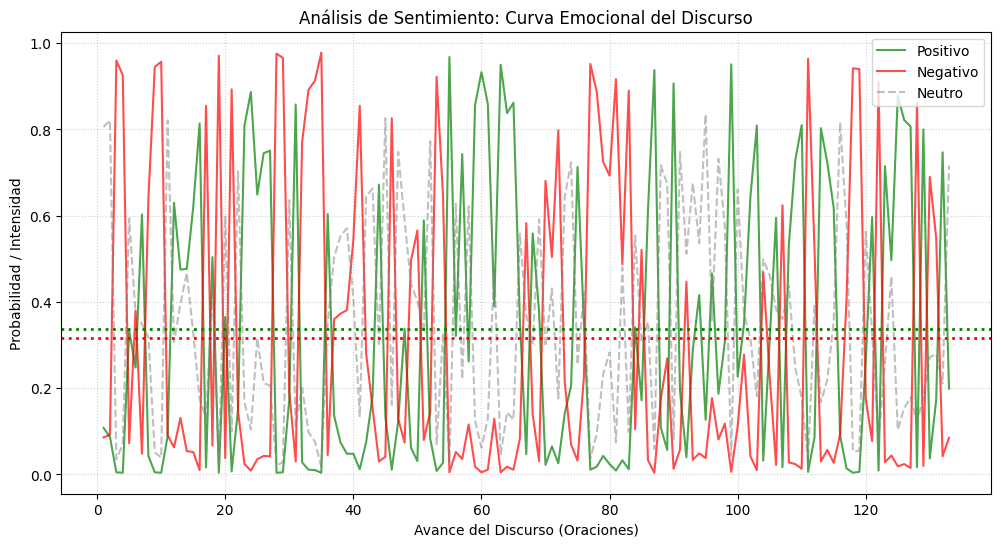


--- CONCLUSIÓN GLOBAL ---
El discurso es predominantemente EQUILIBRADO o INSTITUCIONAL (Neutro).


In [24]:
# --- EJECUCIÓN ---
discurso_crudo = extraer_texto_pdf(archivo_pdf)

if discurso_crudo:
    # Dividimos el discurso en oraciones
    oraciones = nltk.sent_tokenize(discurso_crudo)

    resultados = []

    print(f"Analizando sentimiento de {len(oraciones)} oraciones...")

    for i, oracion in enumerate(oraciones):
        # Limitamos la longitud para evitar errores en el modelo si una oración es gigante
        if len(oracion) > 10:
            # Predecimos el sentimiento
            # Output: NEG (Negativo), NEU (Neutro), POS (Positivo)
            prediction = analyzer.predict(oracion)

            resultados.append({
                'Oracion_Num': i + 1,
                'Texto': oracion[:80] + "...", # Guardamos solo el inicio para la tabla
                'Sentimiento': prediction.output,
                'Probabilidad_POS': round(prediction.probas['POS'], 3),
                'Probabilidad_NEG': round(prediction.probas['NEG'], 3),
                'Probabilidad_NEU': round(prediction.probas['NEU'], 3)
            })

    # --- 3. TABLA DE RESULTADOS ---
    df_sentimiento = pd.DataFrame(resultados)

    print("\n--- MUESTRA DE ANÁLISIS POR ORACIÓN ---")
    print(df_sentimiento.head(10).to_string(index=False))

    # --- 4. VISUALIZACIÓN DE LA CURVA EMOCIONAL ---
    # Vamos a graficar la probabilidad de sentimiento POSITIVO vs NEGATIVO a lo largo del discurso

    plt.figure(figsize=(12, 6))

    # Eje X: Número de oración
    x = df_sentimiento['Oracion_Num']

    # Eje Y: Probabilidades
    plt.plot(x, df_sentimiento['Probabilidad_POS'], label='Positivo', color='green', alpha=0.7)
    plt.plot(x, df_sentimiento['Probabilidad_NEG'], label='Negativo', color='red', alpha=0.7)
    plt.plot(x, df_sentimiento['Probabilidad_NEU'], label='Neutro', color='gray', linestyle='--', alpha=0.5)

    plt.title('Análisis de Sentimiento: Curva Emocional del Discurso')
    plt.xlabel('Avance del Discurso (Oraciones)')
    plt.ylabel('Probabilidad / Intensidad')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)

    # Resaltar promedios
    prom_pos = df_sentimiento['Probabilidad_POS'].mean()
    prom_neg = df_sentimiento['Probabilidad_NEG'].mean()

    plt.axhline(y=prom_pos, color='green', linestyle=':', linewidth=2, label=f'Promedio Positivo ({prom_pos:.2f})')
    plt.axhline(y=prom_neg, color='red', linestyle=':', linewidth=2, label=f'Promedio Negativo ({prom_neg:.2f})')

    plt.show()

    # --- 5. CONCLUSIÓN AUTOMÁTICA ---
    print("\n--- CONCLUSIÓN GLOBAL ---")
    total_pos = df_sentimiento['Probabilidad_POS'].sum()
    total_neg = df_sentimiento['Probabilidad_NEG'].sum()

    if total_pos > total_neg * 1.2: # 20% más positivo
        print("El tono general del discurso es claramente OPTIMISTA y de ESPERANZA.")
    elif total_neg > total_pos * 1.2:
        print("El tono general del discurso es de ALERTA, CRÍTICA o LUCHA (Negativo).")
    else:
        print("El discurso es predominantemente EQUILIBRADO o INSTITUCIONAL (Neutro).")

else:
    print("No se pudo leer el archivo.")